**Insight 1: Overtime Strongly Influences Attrition**<br>
Target Variable: Attrition<br>
Model: Logistic Regression<br>
Input: Entire cleaned dataset (except the target)<br>
Goal: Train model to predict whether an employee will leave the company

In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
# Load the preprocessed dataset
df = pd.read_csv("cleaned_employee_data.csv")

In [53]:
# Set input and target for Insight 1
X = df.drop(columns=['Attrition'])  # Use full dataset excluding the target
y = df['Attrition']  # Target variable

In [55]:
# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [57]:
# Train-Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

In [59]:
# Train Logistic Regression Model
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [61]:
# Make prediction
y_pred = log_model.predict(X_test)
y_probs = log_model.predict_proba(X_test)[:, 1]

Accuracy: 86.85%
Precision: 53.19%
Recall: 40.98%
F1 Score: 46.30%



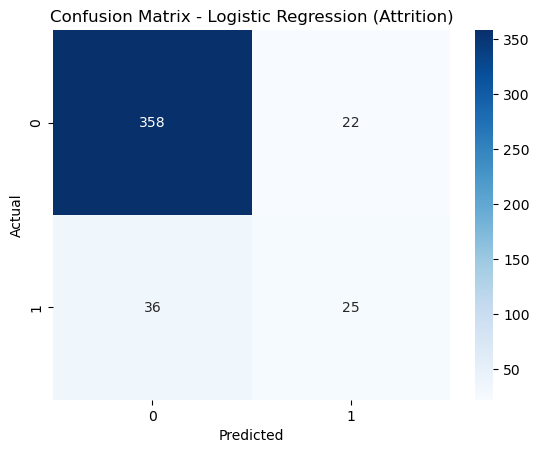

True Positives: 25
True Negatives: 358
False Positives: 22
False Negatives: 36


In [63]:
# Evaluate the model
# Convert metrics to percentages
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred)*100:.2f}%")
print()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Attrition)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# True/False Positives/Negatives
tn, fp, fn, tp = cm.ravel()
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

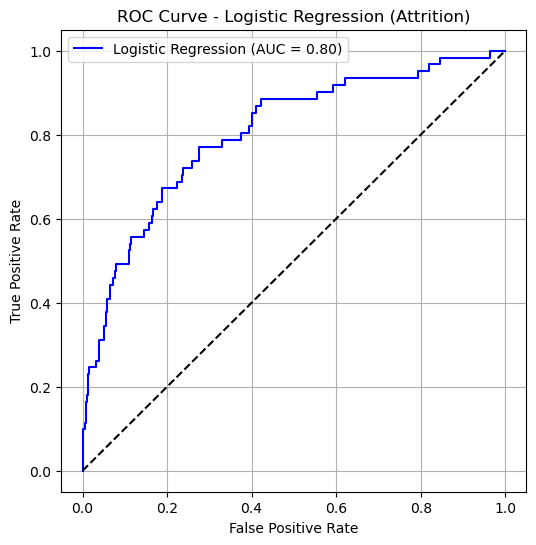

In [65]:
# ROC Curve & AUC
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Logistic Regression (Attrition)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()